# Homework 6  - Logistic Regression without using any libraries. 

## Juhi Malwade

Student Name: Juhi Malwade

Student UT EID: jm97555

---

Date Created: 3/8/26

Date Last Modified: 3/8/26

---

Total Points 20. 



In [1312]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [1313]:
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task 1 - (4 points)
We want to use logistic regerssion to predict if a patient will have heart problems or not. The column "Target" in our datasets includes data about heart disease. If the patient had heart disease, the patient's "Target" value equals 1. Otherwise, "Target" equals 0.

Prepare your data set for predicting heart disease ("Target" column) by using 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 

Split your data into 80% traning data and 20% test data ***without*** using any libraries other than the ones imported above. You must do it manually.

* Do a maximum of **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher/lower. 
* **Visualize your error/costs over the iterations with a plot**.
* No need to add an y-intercept in this task. 

(**4 points** - 3 points for code, 1 point for cost visualization)

In [1314]:
X = heart_df[['Age', 'Sex', 'Chol']].values

heart_df['Target'] = heart_df['Target'].map({'No': 0, 'Yes': 1})
y = heart_df['Target'].values

np.random.seed(3)
index = np.random.permutation(len(X)) #random order of indices
split = int(0.8 * len(X))

train_index = index[:split]
test_index = index[split:]

X_train = X[train_index]
X_test = X[test_index]
y_train = y[train_index]
y_test = y[test_index]

In [1315]:
#Functions copied from in-class notes

def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

def cost_function(X, y, weights):
    m, n = X.shape
    x_dot_weights = X.dot(weights)

    cost = 1.0 / m * (-y.T.dot(np.log(sigmoid(x_dot_weights))) - (1 - y).T.dot(np.log(1 - sigmoid(x_dot_weights))))

    return cost

def gradient(X, y, weights):
    m, n = X.shape
    x_dot_weights = X.dot(weights)

    grad = (1.0 / m )* (sigmoid(x_dot_weights) - y).T.dot(X)

    return grad

In [1316]:
n_feature = 3
weights = np.zeros(n_feature)

cost = cost_function(X_train, y_train, weights)
grad = gradient(X_train, y_train, weights)

print(cost)
print(grad)

0.6931471805599451
[ 0.59917355 -0.04338843  5.56404959]


In [1317]:
# Now we optimize it using Gradient Descent.
num_iterations = 100
learnin_rate = 0.0001

cost_list = []

for i in range(0, num_iterations):

    cost = cost_function(X_train, y_train, weights)
    print("Cost is: ", cost)
    cost_list.append(cost)

    grad = gradient(X_train, y_train, weights)

    weights = weights - learnin_rate * grad

Cost is:  0.6931471805599451
Cost is:  0.6925387062680302
Cost is:  0.6922746619572788
Cost is:  0.6921507957259961
Cost is:  0.692080895854782
Cost is:  0.6920327093369417
Cost is:  0.6919931435400184
Cost is:  0.6919571382095567
Cost is:  0.6919226739485044
Cost is:  0.6918889599310449
Cost is:  0.6918556820153162
Cost is:  0.6918227157670978
Cost is:  0.6917900110801255
Cost is:  0.6917575472482816
Cost is:  0.6917253151376169
Cost is:  0.6916933101829136
Cost is:  0.6916615296273261
Cost is:  0.6916299714316688
Cost is:  0.6915986338472774
Cost is:  0.691567515245805
Cost is:  0.6915366140533366
Cost is:  0.6915059287236178
Cost is:  0.6914754577279495
Cost is:  0.6914451995508611
Cost is:  0.6914151526885526
Cost is:  0.6913853156481189
Cost is:  0.6913556869472776
Cost is:  0.6913262651141716
Cost is:  0.6912970486872788
Cost is:  0.6912680362153165
Cost is:  0.6912392262571737
Cost is:  0.6912106173818363
Cost is:  0.6911822081683199
Cost is:  0.6911539972056012
Cost is:  0.6911

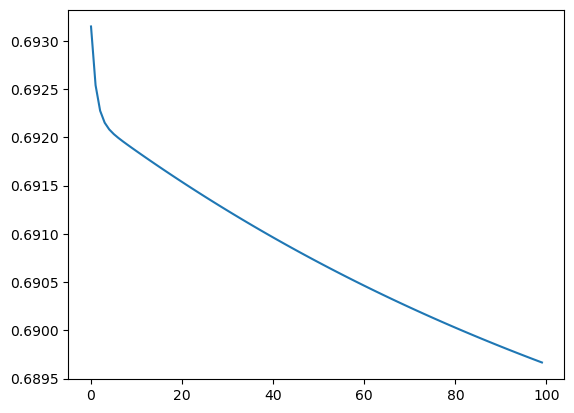

In [1318]:
plt.plot(np.arange(num_iterations), cost_list)
plt.show()

# Task 2 - (4 points)

Cacluate the Accuracy, Precision, Recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. 

You may use equations shown in lecture/slides/examples.

Calcuate the accuracy, precision, recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. (**4 points**)


In [1319]:
def predict(weights, X):
    p = sigmoid(X.dot(weights)) >= 0.5
    return p.astype(int)

In [1320]:
predictions = predict(weights, X_test)
predictions

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0])

In [1321]:
y_test

array([1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [1322]:
true_pos = np.sum((predictions == 1) & (y_test == 1))
true_neg = np.sum((predictions == 0) & (y_test == 0))
false_pos = np.sum((predictions == 1) & (y_test == 0))
false_neg = np.sum((predictions == 0) & (y_test == 1))

accuracy = (true_pos + true_neg) / len(y_test)
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.5410
Precision: 0.4167
Recall: 0.1923
F1 Score: 0.2632


# Task 3 - (4 points)

Add a y-intercept and repeat the above tasks. Do you see any differences after adding the y-intercept?

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [1323]:
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b = np.hstack([np.ones((X_test.shape[0], 1)),  X_test])

In [1324]:
weights = np.zeros(4)
cost = cost_function(X_train_b, y_train, weights)
grad = gradient(X_train_b, y_train, weights)
print(cost)
print(grad)

0.6931471805599451
[ 0.03305785  0.59917355 -0.04338843  5.56404959]


In [1325]:
# Now we optimize it using Gradient Descent. 
num_iterations = 100
learning_rate = 0.0001

cost_list = []

for j in range(0, num_iterations):

    cost = cost_function(X_train_b, y_train, weights)
    print("Cost: ", cost)
    cost_list.append(cost)

    grad = gradient(X_train_b, y_train, weights)

    weights = weights - learning_rate * grad

Cost:  0.6931471805599451
Cost:  0.6925387122785716
Cost:  0.6922746443292219
Cost:  0.6921507537068172
Cost:  0.6920808330003004
Cost:  0.692032628719431
Cost:  0.6919930469250687
Cost:  0.6919570265005673
Cost:  0.6919225475418702
Cost:  0.6918888189668718
Cost:  0.6918555265078581
Cost:  0.6918225456721876
Cost:  0.6917898263270505
Cost:  0.6917573477547201
Cost:  0.6917251008163795
Cost:  0.6916930809449596
Cost:  0.6916612853830852
Cost:  0.6916297120916169
Cost:  0.6915983593221828
Cost:  0.6915672254468335
Cost:  0.6915363088920932
Cost:  0.6915056081121653
Cost:  0.6914751215788129
Cost:  0.69144484777703
Cost:  0.6914147852034795
Cost:  0.6913849323657193
Cost:  0.6913552877819262
Cost:  0.6913258499807012
Cost:  0.6912966175009781
Cost:  0.6912675888919284
Cost:  0.6912387627128926
Cost:  0.6912101375333062
Cost:  0.6911817119326326
Cost:  0.6911534845002935
Cost:  0.6911254538356034
Cost:  0.6910976185477009
Cost:  0.6910699772554839
Cost:  0.6910425285875416
Cost:  0.691015

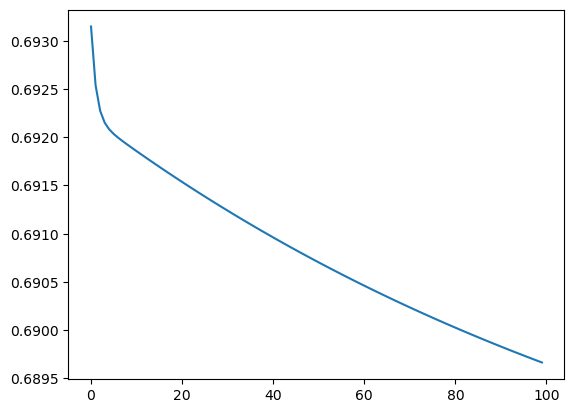

In [1326]:
plt.plot(np.arange(num_iterations), cost_list)
plt.show()

In [1327]:
predictions_b = predict(weights, X_test_b)
predictions_b

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0])

In [1328]:
true_pos = np.sum((predictions_b == 1) & (y_test == 1))
true_neg = np.sum((predictions_b == 0) & (y_test == 0))
false_pos = np.sum((predictions_b == 1) & (y_test == 0))
false_neg = np.sum((predictions_b == 0) & (y_test == 1))

accuracy = (true_pos + true_neg) / len(y_test)
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = 2 *(precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.5410
Precision: 0.4167
Recall: 0.1923
F1 Score: 0.2632


There were no differences in accuracy, precision, recall, and the F1-score. A gradient for the intercept term was added (0.033), which reflects the average error. However, the gradient is so small and doesn't impact the predictions made on the training data.

# Task 4 - Implement the Bold Driver   - (4 points)

Implement the bold driver into your gradient descent implementation, which lets us have a dynamic learning rate. Visualize the costs and print the accuracy/etc. metrics as before. Do not use a y-intercept this time.

Add a stop condition that stop the GD when the cost is not changing more than 0.001 between iterations. 
Describe the results. Did you stop earlier than 100 iterations?
(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)



In [1329]:
weights = np.zeros(3)
learning_rate = 0.001
costs = []

prev_cost = cost_function(X_train, y_train, weights)

for k in range(100):
    grad = gradient(X_train, y_train, weights)
    new_weights = weights - learning_rate * grad
    new_cost = cost_function(X_train, y_train, new_weights)
    costs.append(new_cost)

    if new_cost < prev_cost:
        learning_rate *= 1.05
        weights = new_weights

        if abs(prev_cost - new_cost) < 0.001:
            print("Stopped at iteration:", k)
            break
        prev_cost = new_cost
    else:
        learning_rate *= 0.5

Stopped at iteration: 4


In [1330]:
costs

[0.8935717329943375,
 0.7391752827688675,
 0.7010100571133364,
 0.6931730419449176,
 0.6921760225079119]

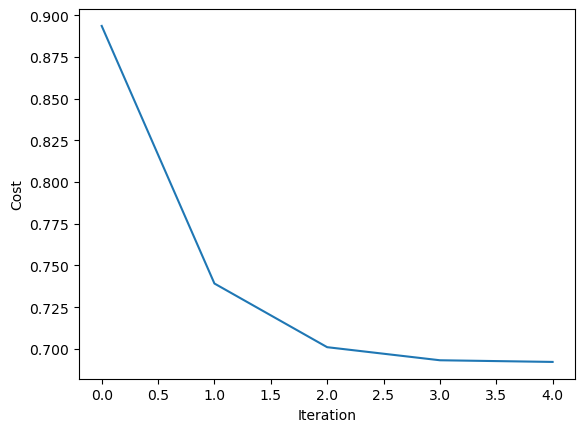

In [1331]:
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [1332]:
predictions_bold = predict(weights, X_test)
predictions_bold

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [1333]:
true_pos = np.sum((predictions_bold == 1) & (y_test == 1))
true_neg = np.sum((predictions_bold == 0) & (y_test == 0))
false_pos = np.sum((predictions_bold == 1) & (y_test == 0))
false_neg = np.sum((predictions_bold == 0) & (y_test == 1))

accuracy  = (true_pos + true_neg) / len(y_test)
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.5738
Precision: nan
Recall: 0.0000
F1 Score: nan


/var/folders/mp/_rmm88r93jxc59v77n11cnn00000gn/T/ipykernel_63950/4293364396.py:7: RuntimeWarning: invalid value encountered in scalar divide
  precision = true_pos / (true_pos + false_pos)


#### The results were not good. The model predicted "0" for every test data point. The accuracy of 0.5738 simply reflects the number of true predictions that were "0" and does not represent the model. It stopped after 4 iterations.

#### When I made the cost difference threshold smaller (0.000001), the predictions were not all "0" but the accuracy went down. Additionally, it used all 100 iterations:

In [1334]:
#Trying agian with smaller cost difference threshold

weights = np.zeros(3)
learning_rate = 0.001
costs = []

prev_cost = cost_function(X_train, y_train, weights)

for k in range(100):
    grad = gradient(X_train, y_train, weights)
    new_weights = weights - learning_rate * grad
    new_cost = cost_function(X_train, y_train, new_weights)
    costs.append(new_cost)

    if new_cost < prev_cost:
        learning_rate *= 1.05
        weights = new_weights

        if abs(prev_cost - new_cost) < 0.000001:
            print("Stopped at iteration:", k)
            break
        prev_cost = new_cost
    else:
        learning_rate *= 0.5

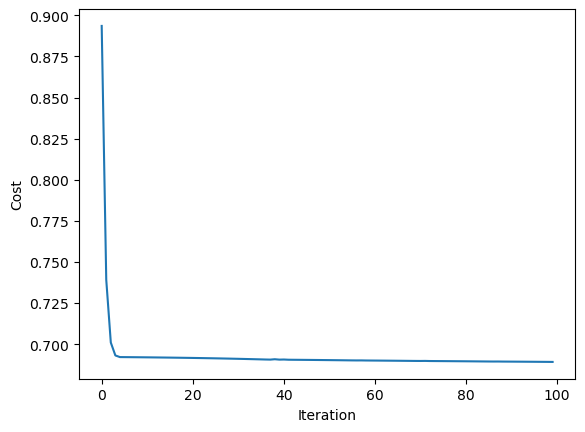

In [1335]:
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [1336]:
predictions_bold = predict(weights, X_test)
predictions_bold

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0])

In [1337]:
true_pos = np.sum((predictions_bold == 1) & (y_test == 1))
true_neg = np.sum((predictions_bold == 0) & (y_test == 0))
false_pos = np.sum((predictions_bold == 1) & (y_test == 0))
false_neg = np.sum((predictions_bold == 0) & (y_test == 1))

accuracy = (true_pos + true_neg) / len(y_test)
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.5082
Precision: 0.3571
Recall: 0.1923
F1 Score: 0.2500


# Task 5 - Implement the L2 norm regularization.  - (4 points)



Modify your Cost and gradient to implement the l2 norm regularization. Repeat the steps taken in prior tasks and describe your result.

 * Use a y-intercept.
 * Do a maximum of 100 iterations as before and report your accuracy, precision, recall and F1 score.
 * Optional: You can stop earlier, if the cost is not changing more than 0.001 between iterations.
 * Optional: You can use the bold driver, if you want. But a bold driver is not required to perform L2 norm regularizaiton.

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [1338]:
lambda_reg = 10

In [1339]:
def cost_function_l2(X, y, weights, lambda_reg):
    n = len(y)
    predictions = sigmoid(X @ weights)
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    cross_entropy = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    l2_penalty = (lambda_reg / (2 * n)) * np.sum(weights[1:] ** 2)
    return cross_entropy + l2_penalty

In [1340]:
def gradient_l2(X, y, weights, lambda_reg):
    n = len(y)
    predictions = sigmoid(X @ weights)
    error = predictions - y
    grad = (X.T @ error) / n
    reg_term = (lambda_reg / n) * weights.copy()
    reg_term[0] = 0

    return grad + reg_term

In [1341]:
weights = np.zeros(4)
learning_rate = 0.001

costs = []
prev_cost = cost_function_l2(X_train_b, y_train, weights, lambda_reg) #Using y-intercept X_train_b from earlier

for p in range(100):
    grad = gradient_l2(X_train_b, y_train, weights, lambda_reg)
    new_weights = weights - learning_rate * grad
    new_cost = cost_function_l2(X_train_b, y_train, new_weights, lambda_reg)
    costs.append(new_cost)

    if new_cost < prev_cost:
        learning_rate *= 1.05
        weights = new_weights
        if abs(prev_cost - new_cost) < 1e-6:
            print("Stopped at iteration:", p)
            break
        prev_cost = new_cost
    else:
        learning_rate *= 0.5

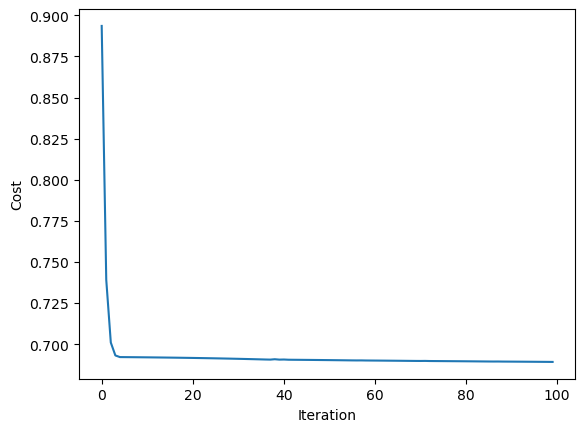

In [1342]:
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [1343]:
predictions = predict(weights, X_test_b)

true_pos = np.sum((predictions == 1) & (y_test == 1))
true_neg = np.sum((predictions == 0) & (y_test == 0))
false_pos = np.sum((predictions == 1) & (y_test == 0))
false_neg = np.sum((predictions == 0) & (y_test == 1))

accuracy = (true_pos + true_neg) / len(y_test)
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.5082
Precision: 0.3571
Recall: 0.1923
F1 Score: 0.2500


The results are the same as the second bold driver model. The accuracy is 0.5082, precision is 0.3571, recall is 0.1923, and f1 score is 0.25. The model used all 100 iterations.